**LAB 8: Build VAE and Visualize Latent Space**

**Step 1: Import Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

**Step 2: Load Dataset (MNIST)**

In [ ]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 46.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.41MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 12.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]


**Step 3: Define VAE Model**

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, 2)
        self.fc_logvar = nn.Linear(400, 2)

        # Decoder
        self.fc2 = nn.Linear(2, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE()

**Step 4: Loss & Optimizer**

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

**Step 5: Training**

In [ ]:
epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for data, _ in train_loader:
        optimizer.zero_grad()

        recon, mu, logvar = model(data)
        loss = loss_function(recon, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

Epoch 1, Loss: 11486466.35
Epoch 2, Loss: 10003443.84
Epoch 3, Loss: 9731601.77
Epoch 4, Loss: 9580689.34
Epoch 5, Loss: 9476088.73


**Step 6: Visualize Latent Space**

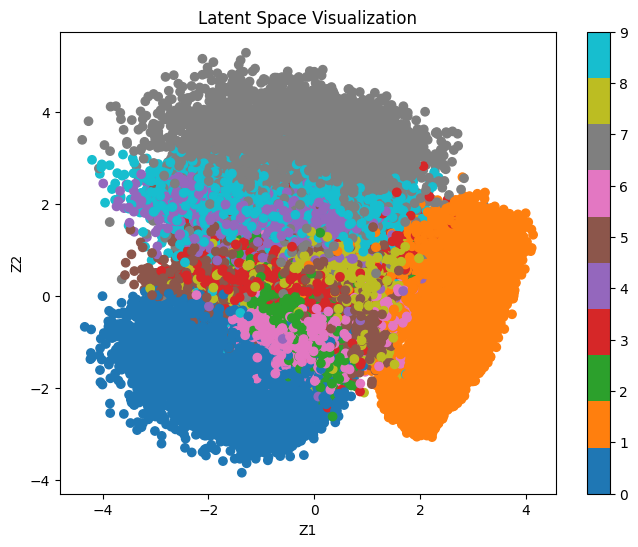

In [ ]:
import numpy as np

model.eval()
z_list = []
labels = []

with torch.no_grad():
    for data, label in train_loader:
        mu, _ = model.encode(data.view(-1, 784))
        z_list.append(mu)
        labels.append(label)

z = torch.cat(z_list).numpy()
labels = torch.cat(labels).numpy()

plt.figure(figsize=(8,6))
plt.scatter(z[:, 0], z[:, 1], c=labels, cmap='tab10')
plt.colorbar()
plt.title("Latent Space Visualization")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.show()

**GAN for Image Synthesis**

In [7]:
import torch
import torch.nn as nn

# =====================
# GENERATOR
# =====================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

# =====================
# DISCRIMINATOR
# =====================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

G = Generator()
D = Discriminator()

criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

# =====================
# TRAIN
# =====================
for epoch in range(5):
    for x, _ in train_loader:
        x = x.view(-1, 784)

        # REAL
        real_labels = torch.ones(x.size(0), 1)
        fake_labels = torch.zeros(x.size(0), 1)

        # =================
        # TRAIN D
        # =================
        z = torch.randn(x.size(0), 100)
        fake = G(z)

        loss_real = criterion(D(x), real_labels)
        loss_fake = criterion(D(fake.detach()), fake_labels)
        loss_D = loss_real + loss_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # =================
        # TRAIN G
        # =================
        loss_G = criterion(D(fake), real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch} | D Loss: {loss_D.item()} | G Loss: {loss_G.item()}")

Epoch 0 | D Loss: 0.971289336681366 | G Loss: 1.2192838191986084
Epoch 1 | D Loss: 1.2021665573120117 | G Loss: 0.7504794001579285
Epoch 2 | D Loss: 1.140616536140442 | G Loss: 0.8385257720947266
Epoch 3 | D Loss: 0.7892956137657166 | G Loss: 1.1427899599075317
Epoch 4 | D Loss: 0.7319051027297974 | G Loss: 1.2661138772964478


**GCN on Citation Data (Cora Dataset)**

In [8]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.2 MB/s eta 0:00:00


In [9]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# =====================
# LOAD DATA
# =====================
dataset = Planetoid(root='data', name='Cora')
data = dataset[0]

# =====================
# MODEL
# =====================
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# =====================
# TRAIN
# =====================
for epoch in range(200):
    model.train()
    optimizer.zero_grad()

    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# =====================
# TEST
# =====================
model.eval()
pred = model(data).argmax(dim=1)

correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())

print(f"Test Accuracy: {acc:.4f}")

Processing...
Done!


Epoch 0, Loss: 1.951132893562317
Epoch 20, Loss: 0.09457933902740479
Epoch 40, Loss: 0.006913051940500736
Epoch 60, Loss: 0.0027635139413177967
Epoch 80, Loss: 0.0019167253049090505
Epoch 100, Loss: 0.0015140455216169357
Epoch 120, Loss: 0.0012436775723472238
Epoch 140, Loss: 0.0010420572943985462
Epoch 160, Loss: 0.0008862211252562702
Epoch 180, Loss: 0.0007634124485775828
Test Accuracy: 0.7860
